
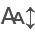

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from itables import init_notebook_mode  
from IPython.display import display
init_notebook_mode(all_interactive=True)

# collect data

In [2]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

# Root directory containing task folders
root_path = "PhysicalAI-Robotics-Manipulation-SingleArm"

# List of all task folders (each folder = one class label)
task_folders = [
    "panda-stack-wide",
    "panda-stack-platforms",
    "panda-stack-platforms-texture",
    "panda-open-cabinet-left",
    "panda-open-cabinet-right",
    "panda-open-drawer"
]

episode_data = []

# Loop through all task folders
for task_folder in task_folders:
    task_label = task_folder  # use folder name as the label
    data_path = os.path.join(root_path, task_folder, "data")

    if not os.path.exists(data_path):
        print(f"Skipping missing path: {data_path}")
        continue

    # Loop through chunk folders
    for chunk_folder in os.listdir(data_path):
        chunk_path = os.path.join(data_path, chunk_folder)
        if not os.path.isdir(chunk_path):
            continue

        for file_name in tqdm(os.listdir(chunk_path), desc=f"Processing {task_label}"):
            if not file_name.endswith(".parquet"):
                continue

            file_path = os.path.join(chunk_path, file_name)
            try:
                df = pd.read_parquet(file_path)

                # Use the first row only (initial state)
                first_row = df.iloc[0]

                # Extract state and action
                state = first_row["observation.state"]
                action = first_row["action"]

                # Flatten into feature dict
                features = {f"state_{i}": val for i, val in enumerate(state)}
                features.update({f"action_{i}": val for i, val in enumerate(action)})

                # Add label and filename
                features["task_label"] = task_label
                features["file"] = file_name

                episode_data.append(features)

            except Exception as e:
                print(f"Error reading {file_path}: {e}")

# Create a DataFrame
df_classification = pd.DataFrame(episode_data)

# Preview
print("✅ Dataset created with shape:", df_classification.shape)
print(df_classification["task_label"].value_counts())


Processing panda-open-drawer: 100%|█████████████████████████████████████████████████| 273/273 [00:00<00:00, 468.27it/s]


✅ Dataset created with shape: (38386, 91)
task_label
panda-stack-platforms            17629
panda-stack-wide                 10243
panda-stack-platforms-texture     6303
panda-open-cabinet-left           1512
panda-open-cabinet-right          1426
panda-open-drawer                 1273
Name: count, dtype: int64


# EDA

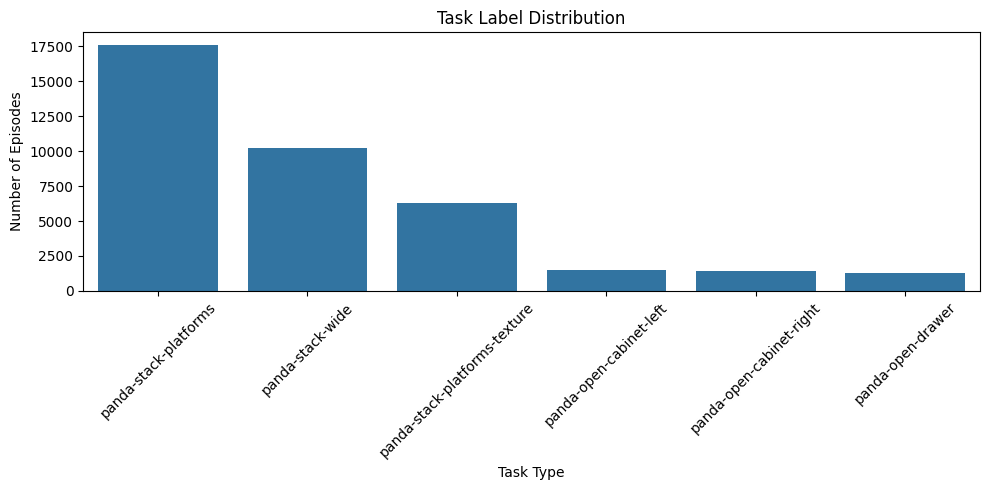

In [4]:
plt.figure(figsize=(10, 5))
sns.countplot(x="task_label", data=df_classification,
              order=df_classification["task_label"].value_counts().index)
plt.title("Task Label Distribution")
plt.xlabel("Task Type")
plt.ylabel("Number of Episodes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

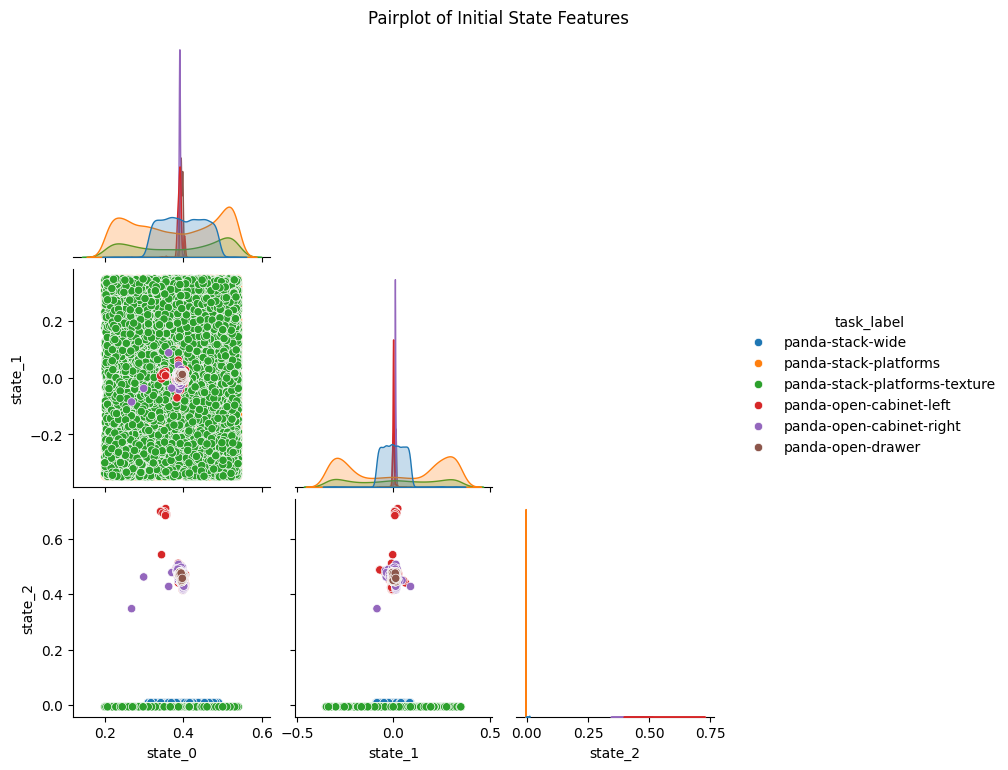

In [6]:
state_cols = [col for col in df_classification.columns if col.startswith("state_")]
sample_cols = state_cols[:3] + ["task_label"]  # choose 3 for readability

sns.pairplot(df_classification[sample_cols], hue="task_label", corner=True)
plt.suptitle("Pairplot of Initial State Features", y=1.02)
plt.show()

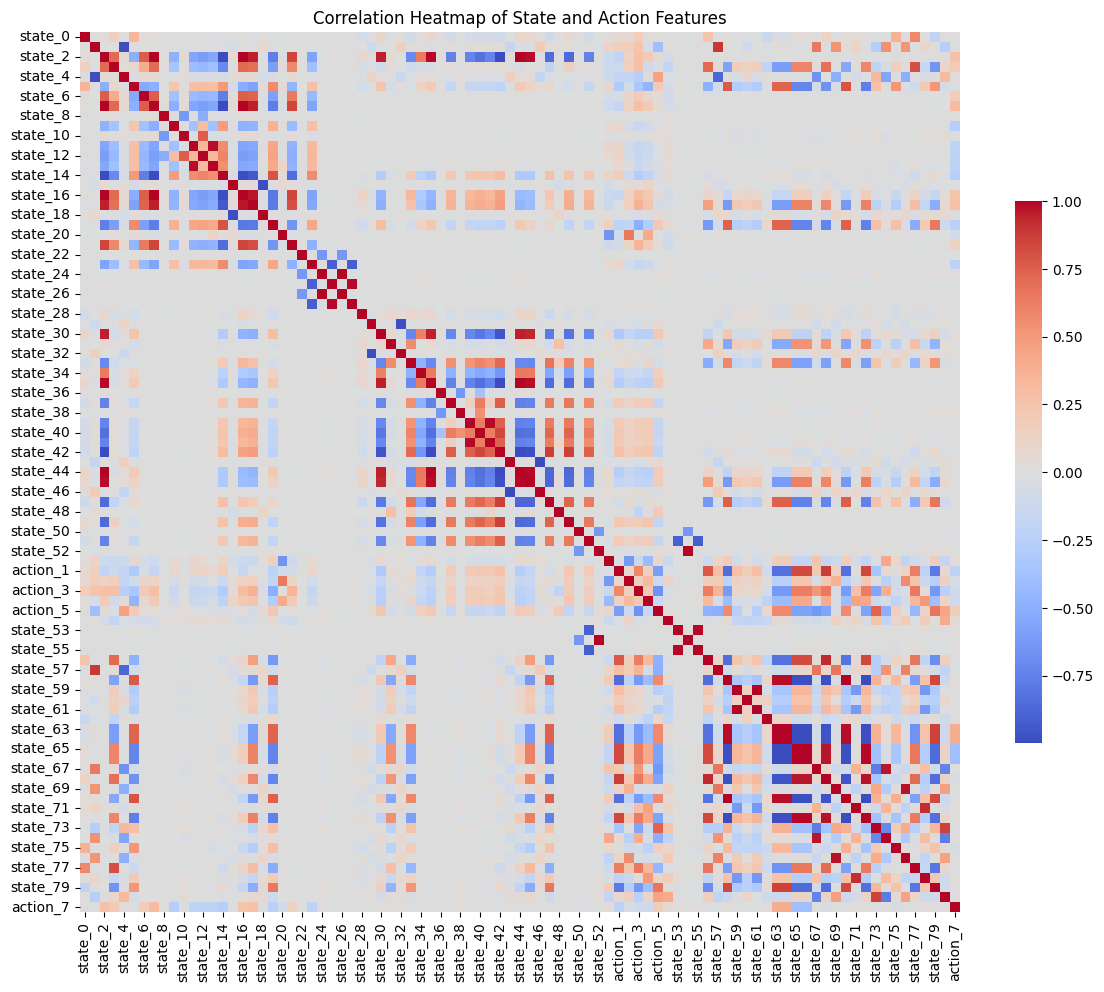

In [7]:
numeric_cols = [col for col in df_classification.columns if col.startswith("state_") or col.startswith("action_")]
corr_matrix = df_classification[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.6})
plt.title("Correlation Heatmap of State and Action Features")
plt.tight_layout()
plt.show()

# baseline model

Accuracy: 0.9120864808543891

Classification Report:
                               precision    recall  f1-score   support

      panda-open-cabinet-left       0.00      0.00      0.00       318
     panda-open-cabinet-right       0.01      0.01      0.01       287
            panda-open-drawer       0.28      0.72      0.41       257
        panda-stack-platforms       1.00      1.00      1.00      3509
panda-stack-platforms-texture       1.00      1.00      1.00      1239
             panda-stack-wide       1.00      1.00      1.00      2068

                     accuracy                           0.91      7678
                    macro avg       0.55      0.62      0.57      7678
                 weighted avg       0.90      0.91      0.90      7678



C:\Users\ABED\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


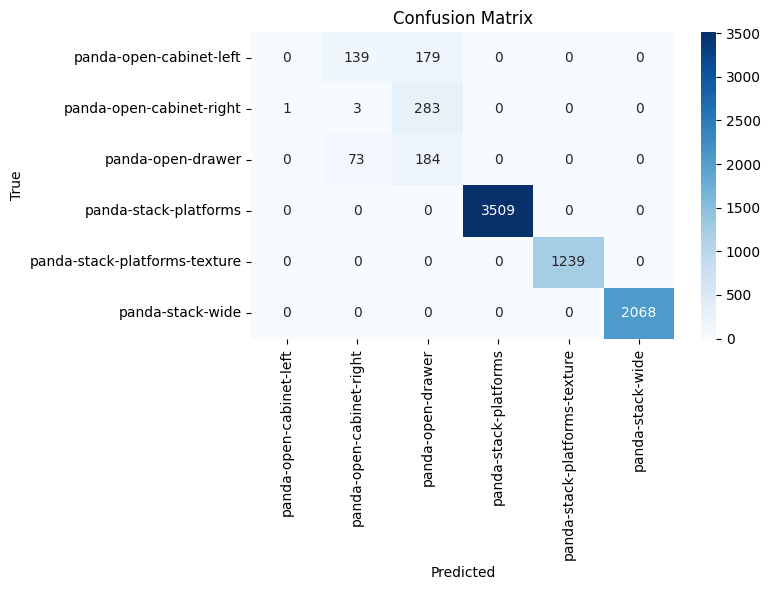

In [8]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare features and labels
feature_cols = [col for col in df_classification.columns if col.startswith("state_") or col.startswith("action_")]
X = df_classification[feature_cols].fillna(0)  # fill NaNs if any

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df_classification["task_label"])

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Predictions
y_pred = model.predict(X_test)

# 6. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 7. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()
